**Checking if images need to be loaded as colored images**

This notebooks describes the following steps of image manipulation:

Do we need three channels or is it ok in gray?
* Uploading and reading multiple image paths into a list using glob
* Split into different channels and compare them
* If all three channels are identical, there is no additional information from the three channels - Images can be loaded as grayscale images.


**Importing the dataset from kaggle**

In [1]:
### ---- Importing the dataset from kaggle --- ###

# Install kaggle
! pip install kaggle

# Monut google drive in colab
from google.colab import drive
drive.mount('/content/drive')

# make a new folder in the root directory
! mkdir ~/.kaggle

# Copy the kaggle-json-file (Token) into the .kaggle-folder
! cp /content/drive/MyDrive/Kaggle_API/kaggle.json ~/.kaggle/

# Change file permission
! chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset
! kaggle datasets download tawsifurrahman/covid19-radiography-database

! unzip covid19-radiography-database.zip

Streaming output truncated to the last 5000 lines.
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7921.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7922.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7923.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7924.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7925.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7926.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7927.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7928.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7929.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-793.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7930.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7931.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7932.png  
 

**Libraries imoprted**

In [2]:
import pandas as pd
import numpy as np

from glob import glob  # is used for pattern matching and filename expansion.

import cv2
import matplotlib.pylab as plt


**Generating a list of file paths**

In [4]:
cxr_covid = glob('/content/COVID-19_Radiography_Dataset/COVID/images/*.png')
cxr_lung_opacity = glob('/content/COVID-19_Radiography_Dataset/Lung_Opacity/images/*.png')
cxr_normal = glob('/content/COVID-19_Radiography_Dataset/Normal/images/*.png')
cxr_viral_pneumonia = glob('/content/COVID-19_Radiography_Dataset/Viral Pneumonia/images/*.png')


mask_covid = glob('/content/COVID-19_Radiography_Dataset/COVID/masks/*.png')
mask_lung_opacity = glob('/content/COVID-19_Radiography_Dataset/Lung_Opacity/masks/*.png')
mask_normal = glob('/content/COVID-19_Radiography_Dataset/Normal/masks/*.png')
mask_viral_pneumonia = glob('/content/COVID-19_Radiography_Dataset/Viral Pneumonia/masks/*.png')

# Concatinate the lists
cxr_all = cxr_covid + cxr_lung_opacity + cxr_normal + cxr_viral_pneumonia
mask_all = mask_covid + mask_lung_opacity + mask_normal + mask_viral_pneumonia

print(cxr_all, '\n',len(cxr_all))
print(mask_all, '\n',len(mask_all))


Output hidden; open in https://colab.research.google.com to view.

**Check if the channels are identical in all CXRs** (if so, images can be loaded as gray scale in order to reduce the size)

In [5]:
# Define a function checking whether the three color channels are the same
def are_channels_identical(img_path):
  # Read image
  img = cv2.imread(img_path)
  # Compare pairwise the arrays of the three different channels. If equal the function returns True
  return np.array_equal(img[:, :, 0], img[:, :, 1]) and np.array_equal(img[:, :, 1], img[:, :, 2])

# Define counter variables
channels_identical = 0
channels_different = 0
# Define a list that will catch the image paths in cases when channels are not identical
errors = []

# Check if channels are identical for all images
for img_path in cxr_all:
  if are_channels_identical(img_path):
    channels_identical += 1
  else:
    errors.append(img_path)
    channels_different += 1

print(f"Number of images with identical channels: {channels_identical}")
print(f"Number of images with different channels: {channels_different}")

#Write results of quality check to txt
file_path = '/content/COVID-19_Radiography_Dataset/errors_summary_cxrs.txt'
with open(file_path, 'w') as file:
    #Add title
    file.write('---- Check channel identity ----\n')
    file.write('\n')

    #Write the errors summary to text
    file.write(f"Total number of images: {len(cxr_all)}" + '\n')
    file.write('\n')
    file.write(f"Channels are identical in {channels_identical} cases." + '\n')
    file.write(f"Channels are NOT identical in: {channels_different} cases." + '\n')
    file.write('\n')

    #Add space and heading
    file.write('\n')
    file.write('\n')
    file.write('---- Errors ----\n')

    #Write the errors to text
    for error in errors:
        file.write(error + '\n')

Number of images with identical channels: 21165
Number of images with different channels: 0


**Display example images in three different channels and gray scale**

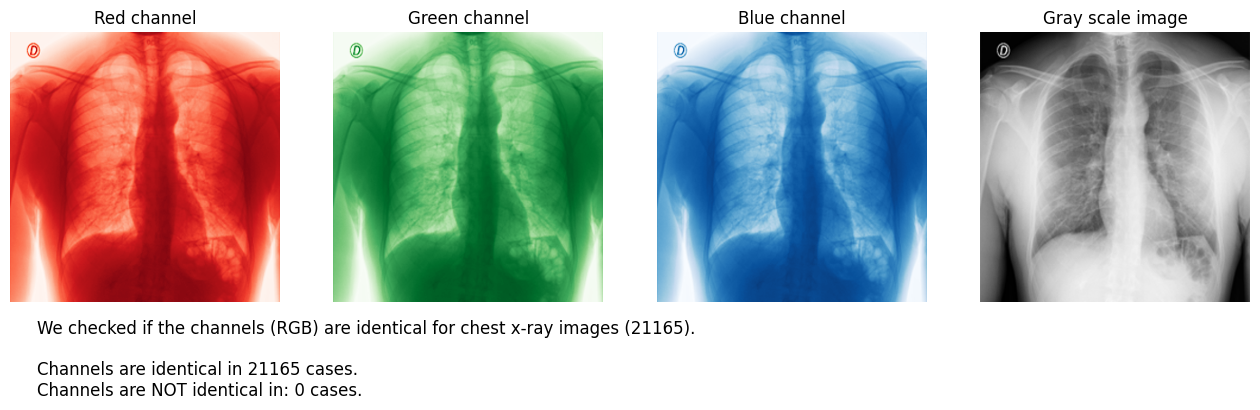

In [6]:
img = cv2.imread(cxr_all[1])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].imshow(img[:,:,0], cmap='Reds')
axs[1].imshow(img[:,:,1], cmap='Greens')
axs[2].imshow(img[:,:,2], cmap='Blues')
axs[3].imshow(img[:,:,0], cmap='gray')
axs[0].axis('off')
axs[1].axis('off')
axs[2].axis('off')
axs[3].axis('off')
axs[0].set_title('Red channel')
axs[1].set_title('Green channel')
axs[2].set_title('Blue channel')
axs[3].set_title('Gray scale image')
axs[0].text(0.1,-0.35,
            f"We checked if the channels (RGB) are identical for chest x-ray images ({len(cxr_all)}).\n\nChannels are identical in {channels_identical} cases.\nChannels are NOT identical in: {channels_different} cases." ,
            size=12, ha="left", transform=axs[0].transAxes)

# Save as pdf and download
plt.savefig('/content/COVID-19_Radiography_Dataset/ChannelsIdentical_cxrs.png', bbox_inches = 'tight')



**Check if the channels are identical in all Masks**

In [7]:
# Define a function checking whether the three color channels are the same
def are_channels_identical(img_path):
  # Read image
  img = cv2.imread(img_path)
  # Compare pairwise the arrays of the three different channels. If equal the function returns True
  return np.array_equal(img[:, :, 0], img[:, :, 1]) and np.array_equal(img[:, :, 1], img[:, :, 2])

# Define counter variables
channels_identical = 0
channels_different = 0
# Define a list that will catch the image paths in cases when channels are not identical
errors = []

# Check if channels are identical for all images
for img_path in mask_all:
  if are_channels_identical(img_path):
    channels_identical += 1
  else:
    errors.append(img_path)
    channels_different += 1

print(f"Number of images with identical channels: {channels_identical}")
print(f"Number of images with different channels: {channels_different}")

#Write results of quality check to txt
file_path = '/content/COVID-19_Radiography_Dataset/errors_summary_masks.txt'
with open(file_path, 'w') as file:
    #Add title
    file.write('---- Check channel identity ----\n')
    file.write('\n')

    #Write the errors summary to text
    file.write(f"Total number of images: {len(cxr_all)}" + '\n')
    file.write('\n')
    file.write(f"Channels are identical in {channels_identical} cases." + '\n')
    file.write(f"Channels are NOT identical in: {channels_different} cases." + '\n')
    file.write('\n')

    #Add space and heading
    file.write('\n')
    file.write('\n')
    file.write('---- Errors ----\n')

    #Write the errors to text
    for error in errors:
        file.write(error + '\n')

Number of images with identical channels: 21165
Number of images with different channels: 0


**Display example images in three different channels and gray scale**

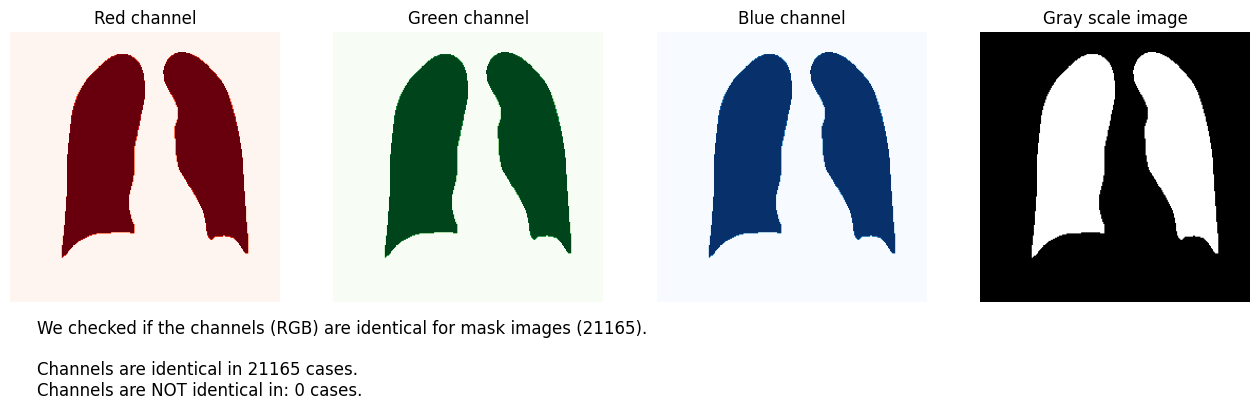

In [8]:
img = cv2.imread(mask_all[1])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].imshow(img[:,:,0], cmap='Reds')
axs[1].imshow(img[:,:,1], cmap='Greens')
axs[2].imshow(img[:,:,2], cmap='Blues')
axs[3].imshow(img[:,:,0], cmap='gray')
axs[0].axis('off')
axs[1].axis('off')
axs[2].axis('off')
axs[3].axis('off')
axs[0].set_title('Red channel')
axs[1].set_title('Green channel')
axs[2].set_title('Blue channel')
axs[3].set_title('Gray scale image')
axs[0].text(0.1,-0.35,
            f"We checked if the channels (RGB) are identical for mask images ({len(cxr_all)}).\n\nChannels are identical in {channels_identical} cases.\nChannels are NOT identical in: {channels_different} cases." ,
            size=12, ha="left", transform=axs[0].transAxes)

# Save as pdf and download
plt.savefig('/content/COVID-19_Radiography_Dataset/ChannelsIdentical_mask.pdf', bbox_inches = 'tight')



**Conclusion**

Channels in all images are identical. Images can be loaded as grayscale images without loosing information. The different channels do not have to be considered for the modeling aproach later on.